# Prophet-Based Waste Forecasting (Multi-Meal)

This notebook uses **Meta's Prophet** to forecast food-waste generation across
four canteen sections (A, B, C, D) with **three meals per day**
(breakfast, lunch, dinner).

Prophet operates on **univariate time series** — one model is fitted per
(section, meal) combination (12 models total).  Exogenous regressors
(`foot_traffic`, `is_holiday`, `has_special_event`) are incorporated via
Prophet's built-in regressor API.

## Workflow Overview
1. Load and preprocess data — reshape to long-format per (section, meal).
2. Time-based train/test split.
3. Baseline Prophet models (default parameters).
4. Optuna Bayesian optimisation of key seasonality/trend parameters.
5. Compare baseline vs tuned (RMSE, MAE, MAPE, R²) per section and meal.
6. 7-day future forecast per section and meal.
7. Reload saved models and verify predictions.
8. Visualise forecasts.


In [10]:
!pip install prophet optuna

In [11]:
# 1. Import Libraries
import os
import pickle
import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')
# Suppress Stan/Prophet logging
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

os.makedirs('models/prophet_optimized', exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

MEALS    = ['breakfast', 'lunch', 'dinner']
TARGET   = 'waste_kg'
SECTIONS = ['a', 'b', 'c', 'd']

# Exogenous regressors to include in each Prophet model
REGRESSORS = ['foot_traffic', 'is_holiday', 'has_special_event']


In [12]:
# 2. Mount Google Drive and set working directory
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    os.chdir('/content/drive/MyDrive/UAB/FDS/campus-waste-intelligence')
    print('Directory changed')
except OSError:
    print("Error: Can't change the Current Working Directory")


Mounted at /content/drive
Directory changed


## 3. Load and Inspect Dataset

In [13]:
def load_and_filter(path: str, meals: list) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f'Raw dataset shape: {df.shape}')
    print('Meal values:', df['meal'].unique())
    df = df[df['meal'].isin(meals)].copy()
    print(f'After filtering: {df.shape}')
    return df

df_raw = load_and_filter('data/waste_features_xgb.csv', MEALS)
df_raw.head()


Raw dataset shape: (2506, 33)
Meal values: ['lunch' 'breakfast' 'closed' 'dinner']
After filtering: (1813, 33)


,meal,waste_kg,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg,foot_traffic,is_holiday,has_special_event,year,month,...,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7,rolling_max_7,section_encoded,section_a,section_b,section_c,section_d
0,lunch,5.17,2.74,1.75,0.68,102.00,0,1,2025,1,...,0.18,2.262857,2.102857,2.249257,5.58,0,True,False,False,False
1,breakfast,4.26,1.74,1.27,1.24,46.25,0,1,2025,1,...,3.18,2.854286,2.396429,2.133197,5.58,0,True,False,False,False
3,dinner,2.72,1.72,0.75,0.25,75.00,0,1,2025,1,...,0.06,2.147143,2.390000,1.978819,5.17,0,True,False,False,False
4,lunch,6.07,3.12,2.06,0.89,138.00,0,1,2025,1,...,1.50,2.842857,2.810000,2.401317,6.07,0,True,False,False,False
5,breakfast,2.96,1.21,0.89,0.85,46.00,0,1,2025,1,...,1.82,3.244286,2.786429,2.090940,6.07,0,True,False,False,False


## 4. Preprocess Data — Reshape to Prophet Format

Prophet requires columns `ds` (datetime) and `y` (target).
Additional regressors are added as extra columns.


In [14]:
def identify_section(row) -> str:
    for s in SECTIONS:
        if row.get(f'section_{s}', False):
            return s
    return None


def build_prophet_dataframes(df_raw: pd.DataFrame) -> dict:
    """
    Returns a nested dict:
        {section: {meal: prophet_df}}

    Each prophet_df has columns: ds, y, + REGRESSORS.
    """
    df = df_raw.copy()
    df['ds']      = pd.to_datetime(df[['year', 'month', 'day']])
    df['section'] = df.apply(identify_section, axis=1)
    df            = df.rename(columns={'meal': 'meal_type'})

    result = {}
    for sec in SECTIONS:
        result[sec] = {}
        sec_df = df[df['section'] == sec]
        for meal in MEALS:
            meal_df = sec_df[sec_df['meal_type'] == meal].copy()
            meal_df = meal_df.sort_values('ds').reset_index(drop=True)
            keep    = ['ds', TARGET] + REGRESSORS
            keep    = [c for c in keep if c in meal_df.columns]
            meal_df = meal_df[keep].rename(columns={TARGET: 'y'})
            result[sec][meal] = meal_df
            print(f'Section {sec.upper()} / {meal}: {len(meal_df)} rows')
    return result


prophet_data = build_prophet_dataframes(df_raw)


Section A / breakfast: 153 rows
Section A / lunch: 147 rows
Section A / dinner: 155 rows
Section B / breakfast: 153 rows
Section B / lunch: 145 rows
Section B / dinner: 158 rows
Section C / breakfast: 157 rows
Section C / lunch: 140 rows
Section C / dinner: 159 rows
Section D / breakfast: 152 rows
Section D / lunch: 135 rows
Section D / dinner: 159 rows


## 5. Time-Based Train/Test Split

In [15]:
TEST_DAYS = 30

def make_prophet_splits(prophet_data: dict, test_days: int = TEST_DAYS) -> dict:
    """
    Returns {section: {meal: {'train': df, 'test': df}}}.
    Cutoff is aligned to the last *test_days* unique dates across all meals
    within a section to ensure consistency.
    """
    splits = {}
    for sec in SECTIONS:
        splits[sec] = {}
        # Determine global cutoff for this section
        all_dates = sorted(set().union(*[
            set(prophet_data[sec][meal]['ds'])
            for meal in MEALS
        ]))
        cutoff = all_dates[-test_days]

        for meal in MEALS:
            df    = prophet_data[sec][meal]
            train = df[df['ds'] < cutoff].copy()
            test  = df[df['ds'] >= cutoff].copy()
            splits[sec][meal] = {'train': train, 'test': test}

        # Summary
        print(f'Section {sec.upper()} | cutoff: {cutoff.date()} | '
              f'train rows: {len(splits[sec]["breakfast"]["train"])} | '
              f'test rows: {len(splits[sec]["breakfast"]["test"])}')
    return splits


splits = make_prophet_splits(prophet_data)


Section A | cutoff: 2025-06-01 | train rows: 123 | test rows: 30
Section B | cutoff: 2025-06-01 | train rows: 129 | test rows: 24
Section C | cutoff: 2025-05-31 | train rows: 132 | test rows: 25
Section D | cutoff: 2025-06-01 | train rows: 127 | test rows: 25


## 6. Evaluation Helpers

In [16]:
def evaluate_prophet(model: Prophet, test_df: pd.DataFrame) -> tuple:
    """Evaluate a Prophet model on *test_df*."""
    forecast = model.predict(test_df)
    pred     = forecast['yhat'].values
    actual   = test_df['y'].values
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) /
                           np.where(actual == 0, 1e-9, actual))) * 100
    r2   = r2_score(actual, pred)
    return rmse, mae, mape, r2


## 7. Baseline Prophet Models (Default Parameters)

In [17]:
import os

def train_baseline_prophet(train_df: pd.DataFrame,
                           regressors: list = REGRESSORS) -> Prophet:
    """Fit a Prophet model with factory-default hyperparameters."""
    m = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False,
    )
    for reg in regressors:
        if reg in train_df.columns:
            m.add_regressor(reg)
    m.fit(train_df)
    return m

baseline_results = []

# Ensure the directory exists before saving models
os.makedirs('models/prophet_optimized', exist_ok=True)

for sec in SECTIONS:
    for meal in MEALS:
        train = splits[sec][meal]['train']
        test  = splits[sec][meal]['test']

        model = train_baseline_prophet(train)
        rmse, mae, mape, r2 = evaluate_prophet(model, test)
        baseline_results.append({
            'section': sec.upper(), 'meal': meal,
            'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2
        })

        with open(f'models/prophet_optimized/baseline_{sec}_{meal}.pkl', 'wb') as f:
            pickle.dump(model, f)

baseline_df = pd.DataFrame(baseline_results)
print('=== Baseline Performance ===')
print(baseline_df.to_string(index=False))


=== Baseline Performance ===
section      meal     RMSE      MAE      MAPE        R2
      A breakfast 1.485845 1.275363 68.795360 -0.160541
      A     lunch 2.532962 2.136290 64.026181  0.098175
      A    dinner 2.447823 1.728030 38.974761 -0.065166
      B breakfast 1.291245 0.979211 56.684268 -0.010588
      B     lunch 4.665180 3.634029 60.010848 -0.003533
      B    dinner 2.392179 1.846732 41.564410  0.062689
      C breakfast 1.590915 1.347644 64.895308  0.127442
      C     lunch 3.069860 2.196414 31.616053  0.241453
      C    dinner 2.132260 1.824625 69.525069  0.040525
      D breakfast 1.816716 1.256241 49.996859  0.095784
      D     lunch 3.812411 3.181759 52.855382 -0.140207
      D    dinner 2.254868 1.863404 52.910568 -0.069287


## 8. Hyperparameter Optimisation with Optuna

Key Prophet hyperparameters to tune:
- `changepoint_prior_scale` — flexibility of the trend
- `seasonality_prior_scale` — strength of seasonality components
- `seasonality_mode`        — 'additive' vs 'multiplicative'
- `holidays_prior_scale`    — strength of holiday effects

One Optuna study is run **per (section, meal)** pair.


In [18]:
def prophet_objective(trial, train_df: pd.DataFrame,
                       regressors: list = REGRESSORS,
                       n_folds: int = 3) -> float:
    """
    Optuna objective: minimise average RMSE from a simple time-series
    cross-validation on the training data.
    """
    cps  = trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True)
    sps  = trial.suggest_float('seasonality_prior_scale', 0.01, 10.0, log=True)
    hps  = trial.suggest_float('holidays_prior_scale', 0.01, 10.0, log=True)
    mode = trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative'])

    n = len(train_df)
    fold_size = n // (n_folds + 1)
    rmse_scores = []

    for fold in range(n_folds):
        split_idx = fold_size * (fold + 1)
        tr = train_df.iloc[:split_idx]
        va = train_df.iloc[split_idx: split_idx + fold_size]
        if len(tr) < 10 or len(va) == 0:
            continue

        m = Prophet(
            changepoint_prior_scale=cps,
            seasonality_prior_scale=sps,
            holidays_prior_scale=hps,
            seasonality_mode=mode,
            yearly_seasonality=False,
            weekly_seasonality=True,
            daily_seasonality=False,
        )
        for reg in regressors:
            if reg in tr.columns:
                m.add_regressor(reg)

        try:
            m.fit(tr)
            fc   = m.predict(va)
            pred = fc['yhat'].values
            actual = va['y'].values
            rmse_scores.append(np.sqrt(mean_squared_error(actual, pred)))
        except Exception:
            return 1e6  # penalise failed fits

    return float(np.mean(rmse_scores)) if rmse_scores else 1e6


N_TRIALS    = 30  # fewer trials — each Prophet fit is slow
best_models = {sec: {} for sec in SECTIONS}
study_logs  = {sec: {} for sec in SECTIONS}

for sec in SECTIONS:
    for meal in MEALS:
        key = f'Section {sec.upper()} / {meal}'
        print(f"\n{'='*50}\nOptimising {key}\n{'='*50}")
        train = splits[sec][meal]['train']

        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=RANDOM_SEED),
            pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=5),
        )

        def obj_wrapper(trial):
            return prophet_objective(trial, train)

        study.optimize(obj_wrapper, n_trials=N_TRIALS, show_progress_bar=True)
        study_logs[sec][meal] = study.trials_dataframe()

        best_params = study.best_params
        print(f'Best params: {best_params}')

        # Re-train on full training data
        final_model = Prophet(
            changepoint_prior_scale=best_params['changepoint_prior_scale'],
            seasonality_prior_scale=best_params['seasonality_prior_scale'],
            holidays_prior_scale=best_params['holidays_prior_scale'],
            seasonality_mode=best_params['seasonality_mode'],
            yearly_seasonality=False,
            weekly_seasonality=True,
            daily_seasonality=False,
        )
        for reg in REGRESSORS:
            if reg in train.columns:
                final_model.add_regressor(reg)
        final_model.fit(train)
        best_models[sec][meal] = final_model

        # Persist
        with open(f'models/prophet_optimized/tuned_{sec}_{meal}.pkl', 'wb') as f:
            pickle.dump(final_model, f)
        with open(f'models/prophet_optimized/best_params_{sec}_{meal}.pkl', 'wb') as f:
            pickle.dump(best_params, f)

        # Quick evaluation
        test = splits[sec][meal]['test']
        rmse, mae, mape, r2 = evaluate_prophet(final_model, test)
        print(f'Test | RMSE: {rmse:.4f}  MAE: {mae:.4f}  '
              f'MAPE: {mape:.2f}%  R²: {r2:.4f}')

print('\nOptimisation completed for all section/meal combinations.')



Optimising Section A / breakfast


  0%|          | 0/30 [00:00<?, ?it/s]

Best params: {'changepoint_prior_scale': 0.01682477291926588, 'seasonality_prior_scale': 0.01306699123790697, 'holidays_prior_scale': 0.06508666098057672, 'seasonality_mode': 'multiplicative'}
Test | RMSE: 1.4558  MAE: 1.2165  MAPE: 54.88%  R²: -0.1140

Optimising Section A / lunch


  0%|          | 0/30 [00:00<?, ?it/s]

Best params: {'changepoint_prior_scale': 0.001085088892790615, 'seasonality_prior_scale': 0.020574391203718588, 'holidays_prior_scale': 0.8938083776005715, 'seasonality_mode': 'multiplicative'}
Test | RMSE: 2.5353  MAE: 1.9730  MAPE: 52.69%  R²: 0.0965

Optimising Section A / dinner


...

  0%|          | 0/30 [00:00<?, ?it/s]

ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


Best params: {'changepoint_prior_scale': 0.00880068475545929, 'seasonality_prior_scale': 0.010253623897736097, 'holidays_prior_scale': 9.700559621829335, 'seasonality_mode': 'multiplicative'}
Test | RMSE: 3.8354  MAE: 3.2568  MAPE: 55.85%  R²: -0.1540

Optimising Section D / dinner


  0%|          | 0/30 [00:00<?, ?it/s]

Best params: {'changepoint_prior_scale': 0.13157287601765633, 'seasonality_prior_scale': 0.039721107273819126, 'holidays_prior_scale': 0.34890188454913873, 'seasonality_mode': 'additive'}
Test | RMSE: 2.1960  MAE: 1.7707  MAPE: 50.68%  R²: -0.0142

Optimisation completed for all section/meal combinations.


## 9. Final Performance Comparison

In [19]:
final_results = []

for sec in SECTIONS:
    for meal in MEALS:
        test = splits[sec][meal]['test']

        # Baseline
        with open(f'models/prophet_optimized/baseline_{sec}_{meal}.pkl', 'rb') as f:
            bl = pickle.load(f)
        b_rmse, b_mae, b_mape, b_r2 = evaluate_prophet(bl, test)

        # Tuned
        tuned = best_models[sec][meal]
        t_rmse, t_mae, t_mape, t_r2 = evaluate_prophet(tuned, test)

        for mname, rmse, mae, mape, r2 in [
            ('Baseline',       b_rmse, b_mae, b_mape, b_r2),
            ('Tuned (Optuna)', t_rmse, t_mae, t_mape, t_r2),
        ]:
            final_results.append({
                'section': sec.upper(), 'model': mname, 'meal': meal,
                'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2
            })

results_df = pd.DataFrame(final_results)
print('=== Final Performance Comparison ===')
print(results_df.to_string(index=False))
results_df.to_csv('prophet_model_comparison.csv', index=False)
print('\nComparison saved to prophet_model_comparison.csv')


=== Final Performance Comparison ===
section          model      meal     RMSE      MAE      MAPE        R2
      A       Baseline breakfast 1.485845 1.275363 68.795360 -0.160541
      A Tuned (Optuna) breakfast 1.455768 1.216539 54.880725 -0.114032
      A       Baseline     lunch 2.532962 2.136290 64.026181  0.098175
      A Tuned (Optuna)     lunch 2.535328 1.972952 52.689736  0.096490
      A       Baseline    dinner 2.447823 1.728030 38.974761 -0.065166
      A Tuned (Optuna)    dinner 2.455950 1.762061 39.128365 -0.072251
      B       Baseline breakfast 1.291245 0.979211 56.684268 -0.010588
      B Tuned (Optuna) breakfast 1.281205 1.066386 69.462271  0.005066
      B       Baseline     lunch 4.665180 3.634029 60.010848 -0.003533
      B Tuned (Optuna)     lunch 4.754758 3.709333 56.685671 -0.042442
      B       Baseline    dinner 2.392179 1.846732 41.564410  0.062689
      B Tuned (Optuna)    dinner 2.360944 1.786251 39.163252  0.087007
      C       Baseline breakfast 1.59091

## 10. 7-Day Forecast

Prophet natively supports future-date forecasting via `make_future_dataframe`.
Exogenous regressors must be supplied for the forecast horizon.
We forward-fill the last known regressor values as a simple approximation.


In [20]:
def build_future_df(model: Prophet, train_df: pd.DataFrame,
                     horizon: int = 7) -> pd.DataFrame:
    """
    Create a future DataFrame for Prophet with regressor values.
    Regressors are forward-filled from the last training observation.
    """
    future = model.make_future_dataframe(periods=horizon, freq='D')
    last_row = train_df.iloc[-1]
    for reg in REGRESSORS:
        if reg in train_df.columns:
            future[reg] = last_row[reg]
    # Keep only the horizon dates (not the training history)
    future = future.tail(horizon).reset_index(drop=True)
    return future


weekly_forecasts = {sec: {} for sec in SECTIONS}

for sec in SECTIONS:
    print(f'\nSection {sec.upper()} 7-day forecast:')
    for meal in MEALS:
        model     = best_models[sec][meal]
        train_df  = splits[sec][meal]['train']
        future_df = build_future_df(model, train_df, horizon=7)
        forecast  = model.predict(future_df)
        preds     = forecast['yhat'].tolist()
        weekly_forecasts[sec][meal] = preds
        print(f'  {meal:10s}: {[round(p, 2) for p in preds]}')

# Persist
forecast_rows = [
    {'section': sec, 'meal_type': meal, 'day': f'Day_{d}', 'forecast_kg': val}
    for sec, meal_dict in weekly_forecasts.items()
    for meal, preds in meal_dict.items()
    for d, val in enumerate(preds, start=1)
]
forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv('prophet_weekly_forecasts.csv', index=False)
print('\nWeekly forecasts saved to prophet_weekly_forecasts.csv')



Section A 7-day forecast:
  breakfast : [2.32, 2.33, 2.34, 2.3, 2.3, 2.32, 2.29]
  lunch     : [4.36, 4.45, 4.46, 4.5, 4.58, 4.47, 4.35]
  dinner    : [3.44, 3.63, 3.58, 3.73, 3.28, 3.43, 3.33]

Section B 7-day forecast:
  breakfast : [2.44, 2.44, 2.44, 2.44, 2.44, 2.45, 2.45]
  lunch     : [6.06, 5.92, 5.26, 5.26, 6.87, 4.5, 5.25]
  dinner    : [4.19, 4.32, 4.26, 4.34, 4.28, 4.38, 4.43]

Section C 7-day forecast:
  breakfast : [4.48, 4.49, 4.5, 4.51, 4.52, 4.54, 4.54]
  lunch     : [6.09, 5.96, 6.33, 6.67, 6.48, 6.56, 7.78]
  dinner    : [6.81, 6.8, 6.93, 6.96, 6.7, 6.91, 7.2]

Section D 7-day forecast:
  breakfast : [1.97, 2.46, 1.83, 2.41, 2.29, 2.1, 2.44]
  lunch     : [3.39, 3.38, 3.4, 3.4, 3.4, 3.42, 3.42]
  dinner    : [3.38, 2.35, 3.17, 3.11, 4.18, 2.56, 3.34]

Weekly forecasts saved to prophet_weekly_forecasts.csv


## 11. Reload Saved Models and Verify Predictions

In [21]:
print('=== Reload & Verify ===')
for sec in SECTIONS:
    for meal in MEALS:
        path = f'models/prophet_optimized/tuned_{sec}_{meal}.pkl'
        with open(path, 'rb') as f:
            reloaded = pickle.load(f)
        test = splits[sec][meal]['test']
        in_mem_rmse   = evaluate_prophet(best_models[sec][meal], test)[0]
        reloaded_rmse = evaluate_prophet(reloaded, test)[0]
        match = '✓' if abs(in_mem_rmse - reloaded_rmse) < 1e-6 else '✗'
        print(f'Section {sec.upper()} / {meal} | '
              f'In-mem RMSE: {in_mem_rmse:.6f} | '
              f'Reloaded RMSE: {reloaded_rmse:.6f} | {match}')


=== Reload & Verify ===
Section A / breakfast | In-mem RMSE: 1.455768 | Reloaded RMSE: 1.455768 | ✓
Section A / lunch | In-mem RMSE: 2.535328 | Reloaded RMSE: 2.535328 | ✓
Section A / dinner | In-mem RMSE: 2.455950 | Reloaded RMSE: 2.455950 | ✓
Section B / breakfast | In-mem RMSE: 1.281205 | Reloaded RMSE: 1.281205 | ✓
Section B / lunch | In-mem RMSE: 4.754758 | Reloaded RMSE: 4.754758 | ✓
Section B / dinner | In-mem RMSE: 2.360944 | Reloaded RMSE: 2.360944 | ✓
Section C / breakfast | In-mem RMSE: 1.500061 | Reloaded RMSE: 1.500061 | ✓
Section C / lunch | In-mem RMSE: 3.133489 | Reloaded RMSE: 3.133489 | ✓
Section C / dinner | In-mem RMSE: 2.069601 | Reloaded RMSE: 2.069601 | ✓
Section D / breakfast | In-mem RMSE: 1.880266 | Reloaded RMSE: 1.880266 | ✓
Section D / lunch | In-mem RMSE: 3.835393 | Reloaded RMSE: 3.835393 | ✓
Section D / dinner | In-mem RMSE: 2.196007 | Reloaded RMSE: 2.196007 | ✓


## 12. Visualise Forecasts: Baseline vs Tuned, by Meal Type

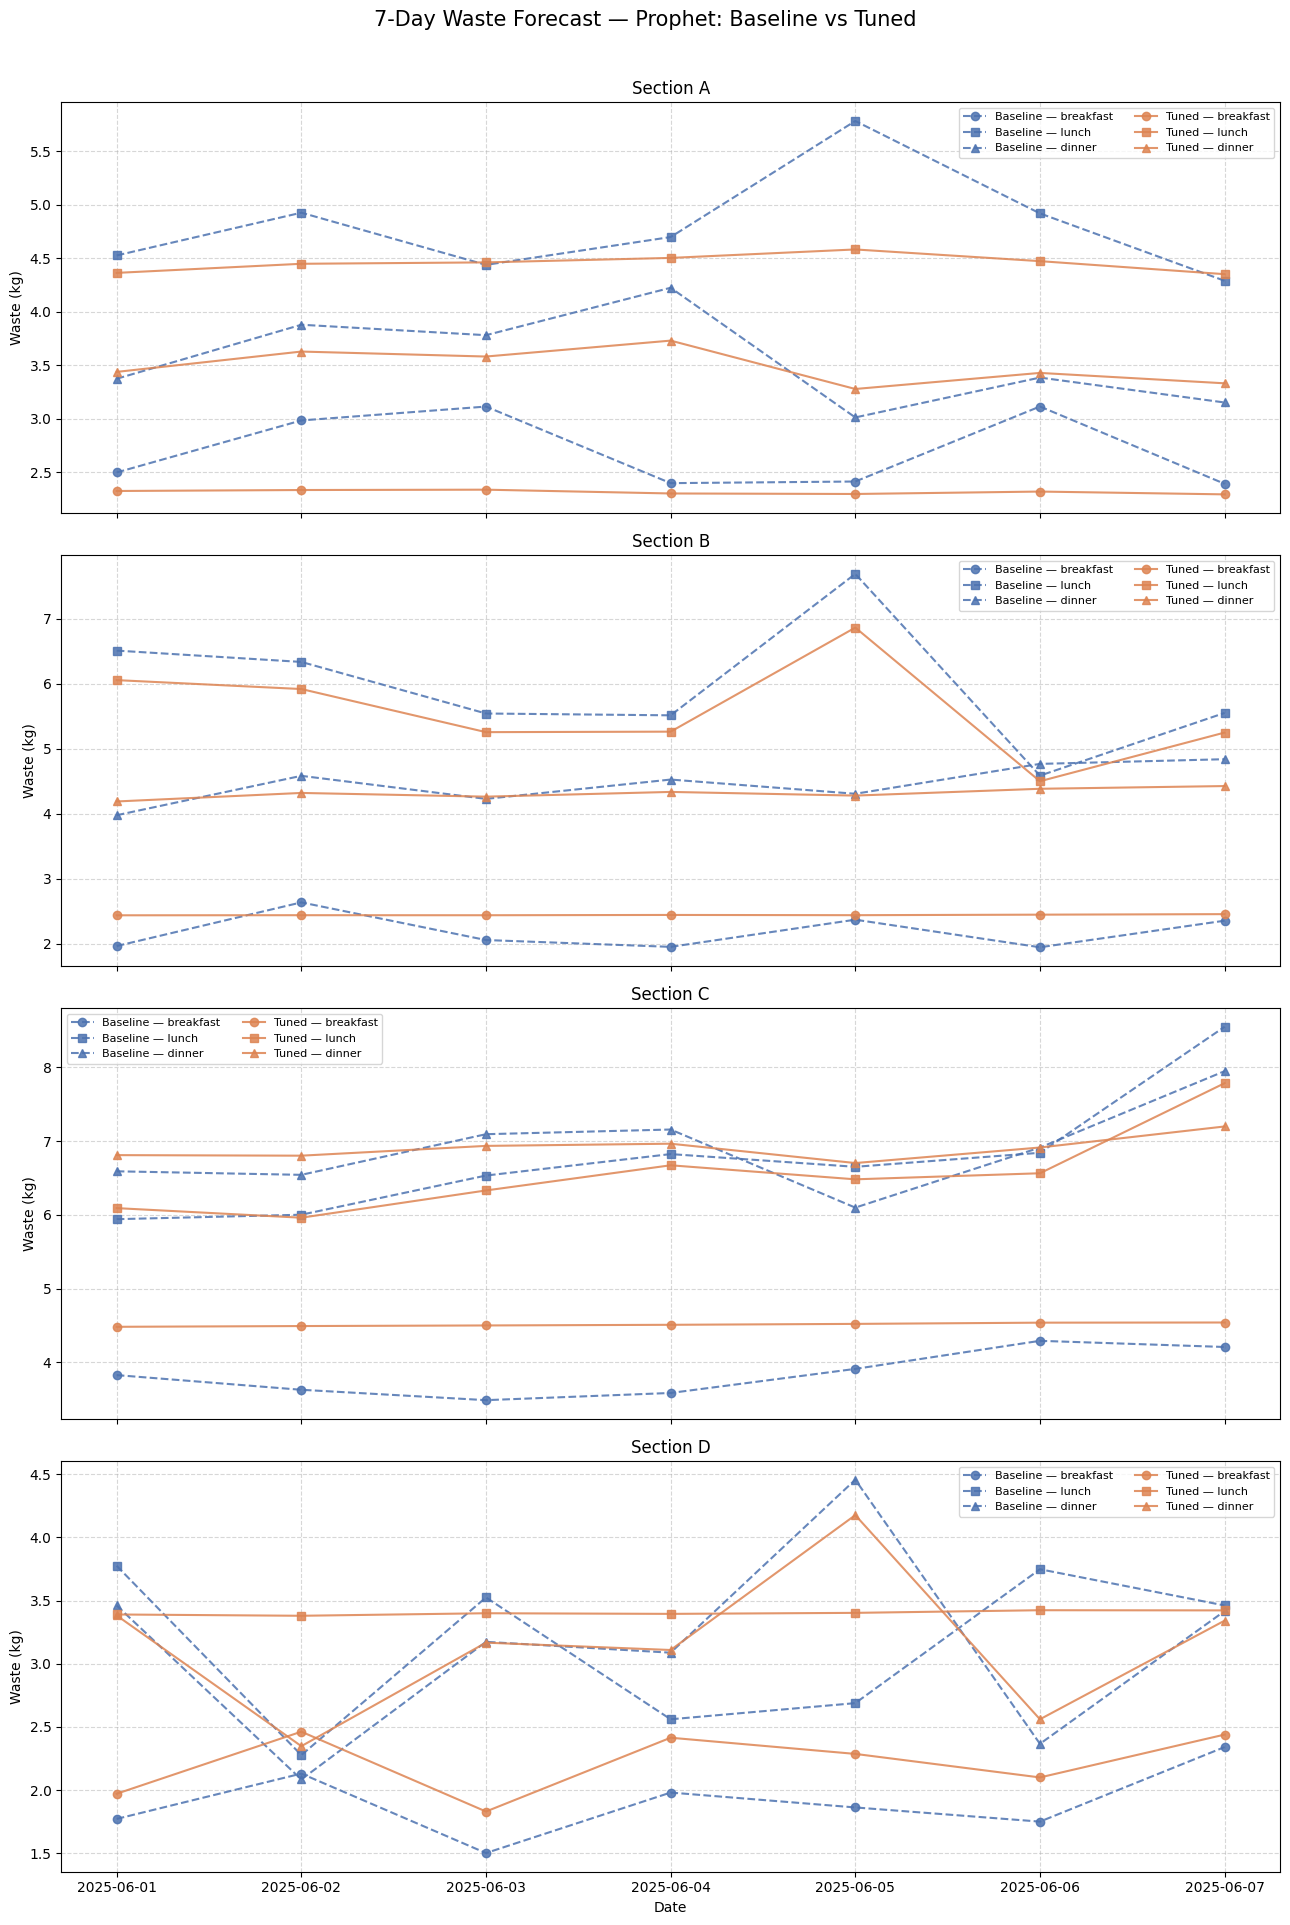

Figure saved to prophet_forecast_comparison.png


In [22]:
all_comparison = {sec: {'Baseline': {}, 'Tuned': {}} for sec in SECTIONS}

for sec in SECTIONS:
    train_data = {meal: splits[sec][meal]['train'] for meal in MEALS}
    for meal in MEALS:
        for label, model in [('Baseline', None), ('Tuned', None)]:
            pkl_prefix = 'baseline' if label == 'Baseline' else 'tuned'
            path = f'models/prophet_optimized/{pkl_prefix}_{sec}_{meal}.pkl'
            with open(path, 'rb') as f:
                m = pickle.load(f)
            future_df = build_future_df(m, train_data[meal], horizon=7)
            forecast  = m.predict(future_df)
            all_comparison[sec][label][meal] = forecast['yhat'].tolist()

# Build plot DataFrame
last_train_date = splits['a']['breakfast']['train']['ds'].max()
forecast_dates  = pd.date_range(start=last_train_date + pd.Timedelta(days=1), periods=7)

plot_rows = [
    {'Date': date, 'Section': sec, 'Model': mname, 'Meal': meal, 'Forecast': val}
    for sec, model_dict in all_comparison.items()
    for mname, meal_dict in model_dict.items()
    for meal, preds in meal_dict.items()
    for date, val in zip(forecast_dates, preds)
]
plot_df = pd.DataFrame(plot_rows)

meal_styles   = {'breakfast': 'o', 'lunch': 's', 'dinner': '^'}
model_palette = {'Baseline': '#4C72B0', 'Tuned': '#DD8452'}

fig, axes = plt.subplots(len(SECTIONS), 1, figsize=(13, 5 * len(SECTIONS)), sharex=True)
fig.suptitle('7-Day Waste Forecast — Prophet: Baseline vs Tuned', fontsize=15)

for i, sec_key in enumerate(SECTIONS):
    ax  = axes[i]
    sub = plot_df[plot_df['Section'] == sec_key]
    for mname in ['Baseline', 'Tuned']:
        for meal in MEALS:
            s = sub[(sub['Model'] == mname) & (sub['Meal'] == meal)]
            ax.plot(s['Date'], s['Forecast'],
                    marker=meal_styles[meal],
                    color=model_palette[mname],
                    linestyle='-' if mname == 'Tuned' else '--',
                    alpha=0.85,
                    label=f'{mname} — {meal}')
    ax.set_title(f'Section {sec_key.upper()}')
    ax.set_ylabel('Waste (kg)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8, ncol=2)

axes[-1].set_xlabel('Date')
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig('prophet_forecast_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to prophet_forecast_comparison.png')
